# Train experts that merge: a small SMAT demo

**Two image tasks · one tiny MLP · CPU by default.** Run all cells to train two
standard fine-tuned (FT) experts and two merge-aware (SMAT) experts, then average
their backbones. No pretrained expert results are loaded.

[Paper](https://arxiv.org/abs/2609.33437) · [Code](https://github.com/egangu/smat) ·
[Five-seed validation](https://github.com/egangu/smat/tree/main/examples/results)

This is an educational experiment, not the paper's CLIP benchmark. It uses
fixed parameters—there is no hyperparameter search in this notebook.

## 1. Setup

Python 3.10+, PyTorch 2.9+. A CPU is sufficient; CUDA is optional. Installation
and the first dataset download need internet. SMAT is implemented below in plain PyTorch and checked against the released
eager stepper. No SMAT package or research dependencies are needed. Existing
compatible installations are reused.


In [1]:
import importlib.util
import subprocess
import sys

# A missing PyTorch installation gets CPU wheels, avoiding CUDA downloads.
if importlib.util.find_spec("torch") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                           "torch>=2.9", "--index-url", "https://download.pytorch.org/whl/cpu"])
for package in ("numpy", "matplotlib", "pandas"):
    if importlib.util.find_spec(package) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])


In [2]:
import copy
import hashlib
import json
import os
import time
import urllib.request
from pathlib import Path

# Also works when only this notebook is opened in Colab.
if Path("examples/demo_utils.py").exists():
    DEMO_DIR = Path("examples").resolve()
elif Path("demo_utils.py").exists():
    DEMO_DIR = Path.cwd()
else:
    DEMO_DIR = Path("smat_demo_files").resolve()
ASSET_REVISION = "4439f2d934b5e65e5b5673099194e10a06fd22cb"
CHECKSUMS = {'demo_utils.py': '0692352edab29aedc8b6e7be45fdc360ee436124e3832cbc1cec81718e447481', 'assets/shared_base.pt': 'e1693268124300b0de932ca05df6be057cda3eb531cb87286814499ec37ef72c', 'assets/shared_base.json': 'f1be0588efc2706c4be64185c6c989bcba9344564f8ccabb40919205f562f6c5'}
for name, expected in CHECKSUMS.items():
    path = DEMO_DIR / name
    path.parent.mkdir(parents=True, exist_ok=True)
    if not path.exists():
        url = f"https://raw.githubusercontent.com/egangu/smat/{ASSET_REVISION}/examples/{name}"
        urllib.request.urlretrieve(url, path)
    assert hashlib.sha256(path.read_bytes()).hexdigest() == expected, f"Asset mismatch: {name}"
sys.path.insert(0, str(DEMO_DIR))

import torch
import pandas as pd
import matplotlib.pyplot as plt
from torch.nn import functional as F
from IPython.display import display
from torch.func import functional_call
from demo_utils import TASKS, TinyMLP, load_data, score, show_examples, show_predictions

# These are the only controls needed for a normal run.
DEVICE = os.environ.get("SMAT_DEMO_DEVICE", "cpu")  # Change to "cuda" for a GPU.
SEED, STEPS, LR, BATCH_SIZE = 0, 1200, 0.001, 128
TA_COEFFICIENT = 1.0
FULL_TEST = False
SETTINGS = {"backend": "eager", "scale": {"alpha_min": 0.1},
            "mask": {"probability": 0.8}, "perturb": {"rms": 0.01},
            "smat": {"interval": 4}}

torch.set_num_threads(2)
device = torch.device(DEVICE)
assert device.type in {"cpu", "cuda"}, "This demo is validated on CPU and CUDA."
assert device.type != "cuda" or torch.cuda.is_available(), "Choose cpu or enable a CUDA runtime."
started = time.perf_counter()
data, splits = load_data(DEMO_DIR / ".cache", full_test=FULL_TEST)
print(f"PyTorch {torch.__version__} | {device} | seed {SEED} | {STEPS} steps/expert")


PyTorch 2.11.0+cu130 | cpu | seed 0 | 1200 steps/expert


## 2. Meet the tasks

MNIST contains handwritten digits; Fashion-MNIST contains clothing images.
Each task has 10 classes. Both share a `784 → 32 → 16` ReLU backbone and have
separate linear heads. Evaluation knows which task an image belongs to.

Per task: **2,000 base / 5,000 expert-training / 1,000 dev** images, disjoint
subsets of the official training split. Test uses a fixed, balanced **2,000**
images from the official test split (`FULL_TEST=True` uses all 10,000).
Images are scaled to [0, 1]. First-run downloads include the complete raw
compressed datasets, about 41 MB. The examples below are fixed dev images.


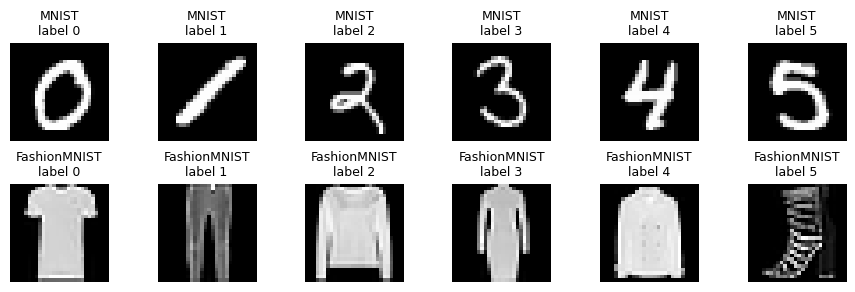

In [3]:
show_examples(data)
plt.show()


## 3. One shared starting point

Load a **105 KB** joint base trained for 400 alternating updates on the small
base subsets. Its recipe and exact split indices are provided in
[`prepare_demo_base.py`](https://github.com/egangu/smat/blob/main/examples/prepare_demo_base.py).
We freeze both heads. All four experts start from this exact checkpoint;
none sees another expert's checkpoint or training data.


In [4]:
metadata = json.loads((DEMO_DIR / "assets/shared_base.json").read_text())
for task in TASKS:
    for split in ("base", "train", "dev"):
        assert splits[task][split] == metadata["splits"][task][split]
base = TinyMLP().to(device)
base.load_state_dict(torch.load(DEMO_DIR / "assets/shared_base.pt", map_location=device, weights_only=True))
base.heads.requires_grad_(False)
rows = {"Shared base": score(dict.fromkeys(TASKS, base), data, "test", device)}
print(f"Parameters: {sum(p.numel() for p in base.parameters()):,}")
print("Shared-base test accuracy:", {k: round(v, 2) for k, v in rows["Shared base"].items()})


Parameters: 25,988
Shared-base test accuracy: {'MNIST': 86.0, 'FashionMNIST': 76.8, 'Mean': 81.4}


## 4. Standard fine-tuning

Adam trains each backbone on its own task. The same visible training loop
is used for FT and SMAT. Identical local data RNG seeds make their batches match;
SMAT's operator RNGs are independent. Each update uses one forward/backward pass.
The `smat_logits` function is introduced in section 6.


In [5]:
def train_expert(base, task, method, data, device, seed=0, steps=STEPS, lr=LR, settings=None):
    model = copy.deepcopy(base).to(device)
    model.heads.requires_grad_(False)
    model.train()
    optimizer = torch.optim.Adam(model.backbone.parameters(), lr=lr)
    settings = settings or SETTINGS
    anchor = {name: p.detach().clone() for name, p in model.named_parameters() if p.requires_grad}
    generators = (torch.Generator().manual_seed(seed+1),
                  torch.Generator(device=device).manual_seed(seed+3),
                  torch.Generator(device=device).manual_seed(seed))
    data_rng = torch.Generator().manual_seed(seed+100)
    images, labels = (x.to(device) for x in data[task]['train'])
    if device.type == 'cuda': torch.cuda.synchronize()
    start = time.perf_counter()
    for step in range(steps):
        indices = torch.randint(len(labels), (BATCH_SIZE,), generator=data_rng).to(device)
        optimizer.zero_grad(set_to_none=True)
        active = method == 'smat' and (step+1) % settings['smat']['interval'] == 0
        if active and settings['smat'].get('components', ('scale', 'mask', 'perturb')):
            logits = smat_logits(model, anchor, images[indices], task, generators, settings)
        else:
            logits = model(images[indices], task)
        F.cross_entropy(logits, labels[indices]).backward()
        optimizer.step()
    if device.type == 'cuda': torch.cuda.synchronize()
    elapsed = time.perf_counter() - start
    for name, value in base.heads.state_dict().items():
        assert torch.equal(value.cpu(), model.heads.state_dict()[name].cpu())
    return model, elapsed


In [6]:
ft_experts, timings = {}, {"FT": 0.0, "SMAT": 0.0}
for task in TASKS:
    ft_experts[task], elapsed = train_expert(base, task, "ft", data, device, seed=SEED, steps=STEPS, lr=LR)
    timings["FT"] += elapsed
rows["FT separate experts"] = score(ft_experts, data, "test", device)
print("Both FT experts trained.")


Both FT experts trained.


## 5. Merge the FT backbones

Compare two fixed mergers, with no coefficient search:

- **AVG:** average the two expert backbones.
- **TA:** add both task vectors to the base, `base + delta_1 + delta_2`.

TA uses coefficient **1.0**; coefficient 0.5 would equal AVG for two experts.
Both retain the shared base's task heads. Separate experts use two backbones;
each merged model uses one backbone with two frozen heads.


In [7]:
def merge(base, experts, weight=0.5):
    """Fixed task heads; interpolate ONLY the two compatible backbones."""
    model = copy.deepcopy(base)
    left = experts[TASKS[0]].backbone.state_dict()
    right = experts[TASKS[1]].backbone.state_dict()
    model.backbone.load_state_dict({name: weight * left[name] + (1-weight) * right[name] for name in left})
    return model

def task_arithmetic(base, experts, coefficient=1.0):
    """Add the sum of task vectors to the shared base; heads remain fixed."""
    model = copy.deepcopy(base)
    origin = base.backbone.state_dict()
    states = [experts[task].backbone.state_dict() for task in TASKS]
    model.backbone.load_state_dict({
        name: origin[name] + coefficient * sum(state[name]-origin[name] for state in states)
        for name in origin
    })
    return model


In [8]:
ft_merged = merge(base, ft_experts)
ft_ta = task_arithmetic(base, ft_experts, TA_COEFFICIENT)
rows["FT AVG"] = score(dict.fromkeys(TASKS, ft_merged), data, "test", device)
rows["FT TA"] = score(dict.fromkeys(TASKS, ft_ta), data, "test", device)
print("FT experts merged with AVG and TA.")


FT experts merged with AVG and TA.


## 6. Train with merging in mind

Every fourth update, SMAT evaluates a simulated merged state:

$$\tilde{\theta}=\theta_0+a\,\frac{m}{1-p}\odot(\theta-\theta_0)+\epsilon.$$

**Scale** the update, **Mask** backbone weight coordinates, and **Perturb** with
noise. Biases are not masked; task heads stay frozen. The other three updates
are ordinary FT. `functional_call` evaluates the simulated parameters while
autograd differentiates back to the original expert weights. The optimizer
always updates the original parameters; no manual restore is needed.

Fixed toy settings: scale minimum 0.1, mask probability 0.8, perturbation RMS
0.01. These differ from the paper's CLIP settings; this notebook performs no
parameter search. For this MLP we explicitly select `backbone.1.weight` and
`backbone.3.weight` for masking, rather than using a Transformer-name heuristic.


In [9]:
def smat_logits(model, anchor, images, task, generators, settings):
    """Differentiable simulated weights; original Parameters are never overwritten."""
    scale_rng, mask_rng, noise_rng = generators
    components = settings.get('smat', {}).get('components', ('scale', 'mask', 'perturb'))
    alpha_min = settings['scale']['alpha_min']
    alpha = alpha_min + (1-alpha_min) * torch.rand((), generator=scale_rng).item() if 'scale' in components else 1.0
    probability = settings['mask']['probability'] if 'mask' in components else 0.0
    rms = settings['perturb']['rms'] if 'perturb' in components else 0.0
    simulated = {}
    for name, parameter in model.named_parameters():
        if not parameter.requires_grad:
            continue  # Frozen task heads are not transformed.
        if probability and name in {'backbone.1.weight', 'backbone.3.weight'}:
            mask = torch.empty_like(parameter, dtype=torch.bool).bernoulli_(1-probability, generator=mask_rng)
            value = anchor[name] + (parameter-anchor[name]) * mask * (alpha/(1-probability))
        else:
            value = torch.lerp(anchor[name], parameter, alpha)
        if rms:
            bound = (3.0 ** 0.5) * rms
            value = value + torch.empty_like(parameter).uniform_(-bound, bound, generator=noise_rng)
        simulated[name] = value
    # Autograd differentiates through Scale and Mask to the expert Parameters.
    return functional_call(model, simulated, (images, task))


In [10]:
smat_experts = {}
for task in TASKS:
    smat_experts[task], elapsed = train_expert(base, task, "smat", data, device, seed=SEED, steps=STEPS, lr=LR, settings=SETTINGS)
    timings["SMAT"] += elapsed
rows["SMAT separate experts"] = score(smat_experts, data, "test", device)
smat_merged = merge(base, smat_experts)
smat_ta = task_arithmetic(base, smat_experts, TA_COEFFICIENT)
rows["SMAT AVG"] = score(dict.fromkeys(TASKS, smat_merged), data, "test", device)
rows["SMAT TA"] = score(dict.fromkeys(TASKS, smat_ta), data, "test", device)
print("Both SMAT experts trained and merged.")


Both SMAT experts trained and merged.


## 7. Compare

Absolute merged accuracy is the primary result. A smaller gap from separate
experts alone does not establish a better merged model. Keep the shared base
in view, too. **This narrow-model stress test illustrates reduced merge damage;
the shared base remains stronger than the merged models.** It does not establish
a better overall model than joint training or a tuned-merger baseline.


,MNIST (%),Fashion (%),Mean (%)
Shared base,86.00,76.80,81.40
FT separate experts,91.65,82.45,87.05
FT AVG,83.00,67.45,75.22
FT TA,69.25,48.00,58.62
SMAT separate experts,91.75,82.05,86.90
SMAT AVG,86.85,73.50,80.18
SMAT TA,80.80,52.45,66.62


AVG: SMAT − FT = +4.950 percentage points
TA: SMAT − FT = +8.000 percentage points
FT: merge gaps {'AVG': 11.825, 'TA': 28.425}; expert training 1.86 s
SMAT: merge gaps {'AVG': 6.725, 'TA': 20.275}; expert training 1.89 s


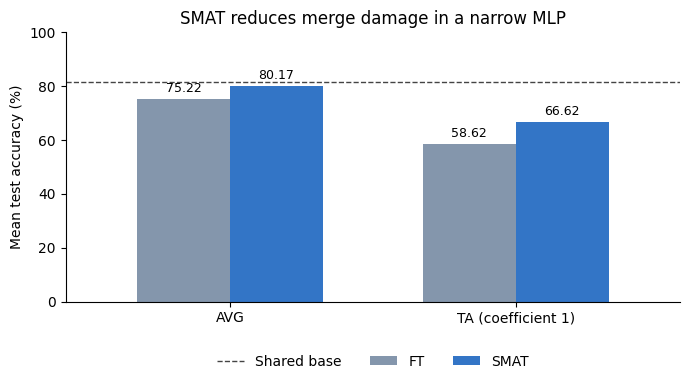

In [11]:
table = pd.DataFrame.from_dict(rows, orient="index")
display(table.round(2).rename(columns={"MNIST": "MNIST (%)", "FashionMNIST": "Fashion (%)", "Mean": "Mean (%)"}))
for merger in ("AVG", "TA"):
    gain = rows[f"SMAT {merger}"]["Mean"] - rows[f"FT {merger}"]["Mean"]
    print(f"{merger}: SMAT − FT = {gain:+.3f} percentage points")
for method in ("FT", "SMAT"):
    gaps = {m: round(rows[f"{method} separate experts"]["Mean"]-rows[f"{method} {m}"]["Mean"], 3) for m in ("AVG", "TA")}
    print(f"{method}: merge gaps {gaps}; expert training {timings[method]:.2f} s")

comparison = pd.DataFrame({method: [rows[f"{method} {m}"]["Mean"] for m in ("AVG", "TA")] for method in ("FT", "SMAT")}, index=["AVG", "TA (coefficient 1)"])
ax = comparison.plot.bar(figsize=(7, 4), color=["#8496ac", "#3375c6"], rot=0, width=0.65)
ax.set(ylabel="Mean test accuracy (%)", ylim=(0, 100), title="SMAT reduces merge damage in a narrow MLP")
ax.axhline(rows["Shared base"]["Mean"], color="#444444", linestyle="--", linewidth=1, label="Shared base")
for bars in ax.containers:
    ax.bar_label(bars, fmt="%.2f", fontsize=9, padding=3)
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


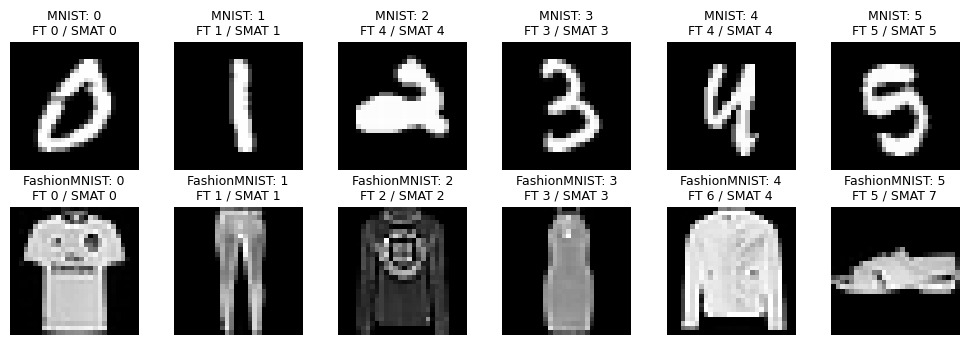

Elapsed since data setup: 9.6 s


In [12]:
# First image of each of six classes in the fixed test subset; no cherry-picking.
show_predictions(ft_merged, smat_merged, data, device)
plt.show()
print(f"Elapsed since data setup: {time.perf_counter() - started:.1f} s")


## 8. Explore

Change `SEED`, `STEPS`, or `TA_COEFFICIENT` in the setup cell, then restart and
Run All. These are learning exercises, not a procedure for choosing settings
using test results. Leave the defaults intact for the reported comparison.

Five predeclared seeds (0–4), using this same base and split, gave mean CPU
gains of **+3.765 points (AVG)** and **+6.475 points (TA)**. These are separate
validation results; the table above is computed live from this run. Individual
runs can be below 3 points (CPU AVG, seed 1: +2.625). CUDA results differ slightly.
This is a deliberately small model demonstrating merge interference, not a
promise of the same gains on other tasks or against a tuned FT/merger baseline.

Training times above include initialization on the first call and exclude
evaluation/downloads. They are not a controlled overhead benchmark and do not
test the paper's <2% claim. See the [validation notes](https://github.com/egangu/smat/blob/main/examples/README.md)
for per-seed results and the reproducible base recipe.
